<a href="https://colab.research.google.com/github/Thixxen/Django-Blog-master/blob/main/URL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# Importar las librerías necesarias
import pandas as pd            # Para trabajar con los datos
import numpy as np             # Para operaciones numéricas
import matplotlib.pyplot as plt # Para graficar
import seaborn as sns         # Para visualizaciones avanzadas
from sklearn.model_selection import train_test_split # Para dividir los datos
from sklearn.ensemble import RandomForestClassifier   # Para el modelo
from sklearn.metrics import classification_report     # Para la evaluación del modelo
import zipfile                 # Para descomprimir el archivo
import requests
from scipy.stats import mode

Información general del conjunto de datos: Detección de URLs de phishing

El conjunto de datos PhiUSIIL Phishing URL Dataset fue diseñado para abordar el problema de detección de URLs maliciosas (phishing) mediante el análisis de características estructurales, de contenido y de comportamiento asociadas con las páginas web. Este dataset incluye métricas técnicas y contextuales relacionadas con URLs, proporcionando un recurso amplio para entrenar y evaluar modelos de clasificación.

La tarea principal asociada a este dataset es clasificar una URL como maliciosa (phishing) o legítima, facilitando el desarrollo de sistemas de ciberseguridad más efectivos.

Atributos principales:
Características estructurales de la URL:

Longitud de la URL (URLLength) y del dominio (DomainLength).
Indicadores de técnicas de ofuscación, como caracteres especiales (HasObfuscation, ObfuscationRatio).
Características de seguridad:

Uso del protocolo HTTPS (IsHTTPS).
Presencia de redirecciones y referencias externas (NoOfURLRedirect, NoOfExternalRef).
Características del contenido web:

Elementos visibles en la página web, como títulos (HasTitle), formularios (HasSubmitButton) y campos ocultos (HasHiddenFields).
Información contextual, como la existencia de íconos de redes sociales (HasSocialNet) o favicons (HasFavicon).
Indicadores de confianza:

Similitud del dominio con nombres legítimos (URLSimilarityIndex, TLDLegitimateProb).
Información sobre la estructura del sitio (LineOfCode, LargestLineLength).
Variable objetivo (label):

Clasifica cada URL como 1 (phishing) o 0 (no phishing).
Tamaño y formato:
Número de registros: 235,795.
Número de atributos: 56.
Formato: CSV.
Este dataset es un recurso valioso para desarrollar y evaluar modelos de clasificación que ayuden a proteger a los usuarios contra amenazas cibernéticas relacionadas con phishing.

In [9]:
# Importar las librerías necesarias
import pandas as pd             # Para trabajar con los datos
import numpy as np              # Para operaciones numéricas
import matplotlib.pyplot as plt # Para graficar
import seaborn as sns           # Para visualizaciones avanzadas
from sklearn.model_selection import train_test_split  # Para dividir los datos
from sklearn.ensemble import RandomForestClassifier  # Para el modelo
from sklearn.metrics import classification_report    # Para la evaluación del modelo
from scipy.stats import mode                         # Para cálculos estadísticos avanzados

# Cargar el dataset desde el archivo CSV
dataset_path = 'PhiUSIIL_Phishing_URL_Dataset.csv'  # Asegúrate de que el archivo esté en el entorno de Colab
df = pd.read_csv(dataset_path)

# Ver las primeras filas del dataset
print(df.head())

# Extraer las características (X) y las etiquetas (y)
# Aquí asumimos que la columna 'label' es la etiqueta (phishing/no phishing) y el resto son características
X = df.drop(columns=['label'])  # Las características son todas las columnas excepto 'label'
y = df['label']  # La etiqueta es la columna 'label'

# Imprimir metadatos y variables del dataset para referencia
print("\nDescripción del dataset:")
print(df.info())  # Información básica sobre el dataset, incluyendo tipos de datos

print("\nDescripción estadística del dataset:")
print(df.describe())  # Descripción estadística de las variables

print("\nDistribución de las clases:")
print(y.value_counts())  # Ver cómo están distribuidas las clases (phishing/no phishing)




                                  URL  URLLength                      Domain  \
0    https://www.southbankmosaics.com         31    www.southbankmosaics.com   
1            https://www.uni-mainz.de         23            www.uni-mainz.de   
2      https://www.voicefmradio.co.uk         29      www.voicefmradio.co.uk   
3         https://www.sfnmjournal.com         26         www.sfnmjournal.com   
4  https://www.rewildingargentina.org         33  www.rewildingargentina.org   

   DomainLength  IsDomainIP  TLD  URLSimilarityIndex  CharContinuationRate  \
0            24           0  com               100.0              1.000000   
1            16           0   de               100.0              0.666667   
2            22           0   uk               100.0              0.866667   
3            19           0  com               100.0              1.000000   
4            26           0  org               100.0              1.000000   

   TLDLegitimateProb  URLCharProb  ...  Pay  Crypt

Atributos Principales:
url: La URL completa del sitio web, que puede contener subdominios y diferentes parámetros.
domain: Dominio principal de la URL, usado para identificar la procedencia del sitio.
protocol: Protocolo utilizado en la URL (por ejemplo, http, https, ftp, etc.), lo que puede influir en la seguridad del sitio.
special_chars: Número de caracteres especiales presentes en la URL, que pueden ser indicativos de intentos de manipulación de la URL.
subdomains: Número de subdominios presentes en la URL, lo cual puede ayudar a identificar patrones comunes en sitios de phishing.
url_length: Longitud total de la URL. Las URLs muy largas o muy cortas pueden ser una señal de un sitio malicioso.
dots: Número de puntos (.) presentes en la URL, que pueden indicar la complejidad de la URL.
slashes: Número de barras inclinadas (/) en la URL, que también es un indicador de la estructura de la página web.
params: Número de parámetros en la URL. Una cantidad inusual de parámetros puede sugerir que el sitio está diseñado para robar datos.
at_sign: Indica si la URL contiene el símbolo '@', que es comúnmente utilizado en ataques de phishing.
https: Indica si la URL utiliza el protocolo HTTPS, lo cual es un indicativo de mayor seguridad.
contains_phishing: Indica si la URL contiene la palabra "phishing", lo cual podría ser un signo de que el sitio está relacionado con actividades fraudulentas.
Variable de Salida (Etiqueta):
class: Clasificación de la URL en dos categorías:
phishing: URL que pertenece a un sitio de phishing, diseñado para engañar al usuario y robar información.
legitimate: URL que pertenece a un sitio web legítimo y seguro, sin intenciones maliciosas.

.EXPLORACION DE LOS DATOS

In [39]:
import pandas as pd

# Cargar el archivo CSV con el dataset de phishing URL (asegúrate de tener la ruta correcta)
df = pd.read_csv('PhiUSIIL_Phishing_URL_Dataset.csv')

# Realizar alguna limpieza, si es necesario (ejemplo: eliminar columnas innecesarias, manejar valores nulos, etc.)
df_cleaned = df.dropna()  # Ejemplo de limpieza, eliminando filas con valores nulos

# Imprimir las dimensiones del dataset original y limpio
print(f'Filas y Columnas del archivo Original: {df.shape}')
print(f'Filas y Columnas después de la limpieza: {df_cleaned.shape}')


Filas y Columnas del archivo Original: (235795, 55)
Filas y Columnas después de la limpieza: (235795, 55)


.INFORMACION DE VARIABLES

In [40]:
# Imprimir la información del DataFrame original
print("Info DataSet Original")
df.info()


Info DataSet Original
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 55 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   URL                         235795 non-null  object 
 1   URLLength                   235795 non-null  int64  
 2   Domain                      235795 non-null  object 
 3   DomainLength                235795 non-null  int64  
 4   IsDomainIP                  235795 non-null  int64  
 5   TLD                         235795 non-null  object 
 6   URLSimilarityIndex          235795 non-null  float64
 7   CharContinuationRate        235795 non-null  float64
 8   TLDLegitimateProb           235795 non-null  float64
 9   URLCharProb                 235795 non-null  float64
 10  TLDLength                   235795 non-null  int64  
 11  NoOfSubDomain               235795 non-null  int64  
 12  HasObfuscation              235795 non-null  int64

.VALORES NULL

In [41]:
# Imprimir si existen valores nulos en el dataset
valores_nulos_por_columna = df.isnull().sum()
print(f"Cantidad de valores nulos por columna: \n\n{valores_nulos_por_columna}")


Cantidad de valores nulos por columna: 

URL                           0
URLLength                     0
Domain                        0
DomainLength                  0
IsDomainIP                    0
TLD                           0
URLSimilarityIndex            0
CharContinuationRate          0
TLDLegitimateProb             0
URLCharProb                   0
TLDLength                     0
NoOfSubDomain                 0
HasObfuscation                0
NoOfObfuscatedChar            0
ObfuscationRatio              0
NoOfLettersInURL              0
LetterRatioInURL              0
NoOfDegitsInURL               0
DegitRatioInURL               0
NoOfEqualsInURL               0
NoOfQMarkInURL                0
NoOfAmpersandInURL            0
NoOfOtherSpecialCharsInURL    0
SpacialCharRatioInURL         0
IsHTTPS                       0
LineOfCode                    0
LargestLineLength             0
HasTitle                      0
Title                         0
DomainTitleMatchScore         0

In [42]:
# imprime informacion sobre el dataset
df.describe()

,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
count,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,...,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000
mean,34.573095,21.470396,0.002706,78.430778,0.845508,0.260423,0.055747,2.764456,1.164758,0.002057,...,0.237007,0.023474,0.486775,26.075689,6.333111,10.522305,65.071113,2.377629,49.262516,0.571895
std,41.314153,9.150793,0.051946,28.976055,0.216632,0.251628,0.010587,0.599739,0.600969,0.045306,...,0.425247,0.151403,0.499826,79.411815,74.866296,22.312192,176.687539,17.641097,161.027430,0.494805
min,13.000000,4.000000,0.000000,0.155574,0.000000,0.000000,0.001083,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,16.000000,0.000000,57.024793,0.680000,0.005977,0.050747,2.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,27.000000,20.000000,0.000000,100.000000,1.000000,0.079963,0.057970,3.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,8.000000,2.000000,6.000000,12.000000,0.000000,10.000000,1.000000
75%,34.000000,24.000000,0.000000,100.000000,1.000000,0.522907,0.062875,3.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,29.000000,8.000000,15.000000,88.000000,1.000000,57.000000,1.000000
max,6097.000000,110.000000,1.000000,100.000000,1.000000,0.522907,0.090824,13.000000,10.000000,1.000000,...,1.000000,1.000000,1.000000,8956.000000,35820.000000,6957.000000,27397.000000,4887.000000,27516.000000,1.000000


In [43]:
# imprime si existe duplicados
df[df.duplicated()]

,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label


In [44]:
# imprime la cantidad de filas repetidas
print(f"La cantidad de filas repetida es: {df[df.duplicated()].shape[0]}")

La cantidad de filas repetida es: 0


In [45]:
# Verificar los nombres de las columnas del DataFrame
print(df.columns)


Index(['URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD',
       'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb',
       'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation',
       'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL',
       'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL',
       'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL',
       'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS',
       'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title',
       'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots',
       'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription',
       'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet',
       'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay',
       'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS',
       'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'labe

.Columna Length

In [51]:
# Contar las frecuencias de la columna 'URLLength'
print("\nFrecuencias de la columna 'URLLength':")
print(df['URLLength'].value_counts())




Frecuencias de la columna 'URLLength':
URLLength
26     15561
25     14670
24     14515
27     14011
23     13829
       ...  
822        1
315        1
324        1
321        1
487        1
Name: count, Length: 482, dtype: int64


In [49]:
# Imprimir los nombres de las columnas para verificar la estructura del dataset
print("Columnas del dataset:")
print(df.columns)


Columnas del dataset:
Index(['URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD',
       'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb',
       'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation',
       'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL',
       'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL',
       'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL',
       'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS',
       'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title',
       'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots',
       'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription',
       'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet',
       'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay',
       'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS',
       'NoOfSelfRef', 'NoOfEmptyRef', 'N

<Axes: xlabel='HasObfuscation', ylabel='count'>

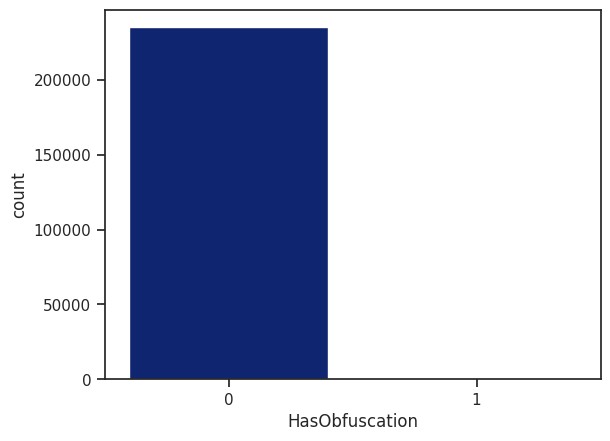

In [15]:
# Establece el estilo y la paleta de colores para las gráficas
sns.set(style="ticks", palette="dark")

# Crea un gráfico de barras que cuenta las ocurrencias de cada valor en la columna
sns.countplot(data=df, x='HasObfuscation')


In [16]:
# Contar las frecuencias de la columna 'HasCopyrightInfo'
print("\nFrecuencias de la columna 'HasCopyrightInfo':")
print(df['HasCopyrightInfo'].value_counts())


Frecuencias de la columna 'HasCopyrightInfo':
HasCopyrightInfo
0    121016
1    114779
Name: count, dtype: int64


<Axes: xlabel='HasCopyrightInfo', ylabel='count'>

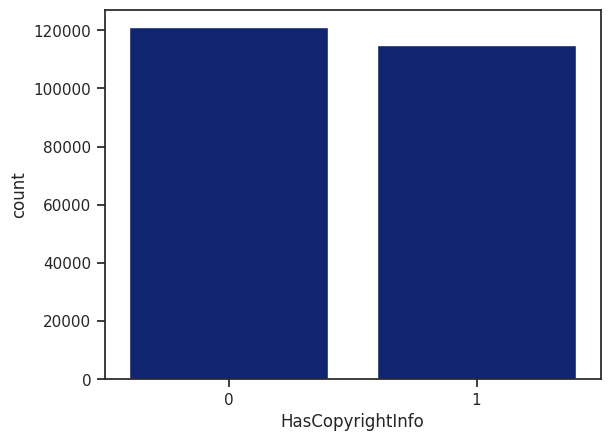

In [17]:
# Establece el estilo y la paleta de colores para las gráficas
sns.set(style="ticks", palette="dark")

# Crea un gráfico de barras que cuenta las ocurrencias de cada valor en la columna
sns.countplot(data=df, x='HasCopyrightInfo')

1. HasObfuscation
Esta columna probablemente indique si la URL contiene técnicas de ofuscación (como la codificación de caracteres o el uso de caracteres invisibles) que se utilizan comúnmente en ataques de phishing para ocultar su verdadero propósito. Los valores altos en esta columna (más de 200,000 registros) sugieren que la mayoría de las URLs en el dataset tienen alguna forma de ofuscación.

Posibles Implicaciones:

Alta frecuencia de ofuscación: Si más de 200,000 URLs presentan ofuscación, esto podría ser una señal de que muchas de las URLs en el dataset son de phishing, ya que los atacantes utilizan técnicas de ofuscación para engañar a los usuarios y evadir los filtros de seguridad.
URLs legítimas: Si una proporción significativa de URLs legítimas también contiene algún tipo de ofuscación (aunque sea menor), se podría necesitar un análisis más detallado para distinguir entre los casos legítimos y los de phishing, basándose en otros atributos.

2. HasCopyrightInfo
La columna HasCopyrightInfo indica si la URL contiene información de copyright. Esto puede ser relevante para identificar URLs legítimas, ya que muchas páginas web legítimas incluyen información de derechos de autor, mientras que los sitios de phishing pueden no tener esta información, o tenerla de forma incorrecta o engañosa.

Posibles Implicaciones:

Frecuencia alta en URLs legítimas: Si más de 120,000 URLs contienen información de copyright, es probable que estas sean URLs legítimas, ya que los sitios web confiables a menudo incluyen esta información.
URLs de phishing sin copyright: Las URLs de phishing, al ser sitios falsificados, pueden carecer de información de copyright, lo que podría ayudar a distinguirlas de las URLs legítimas.

ValueError: num must be an integer with 1 <= num <= 12, not 13

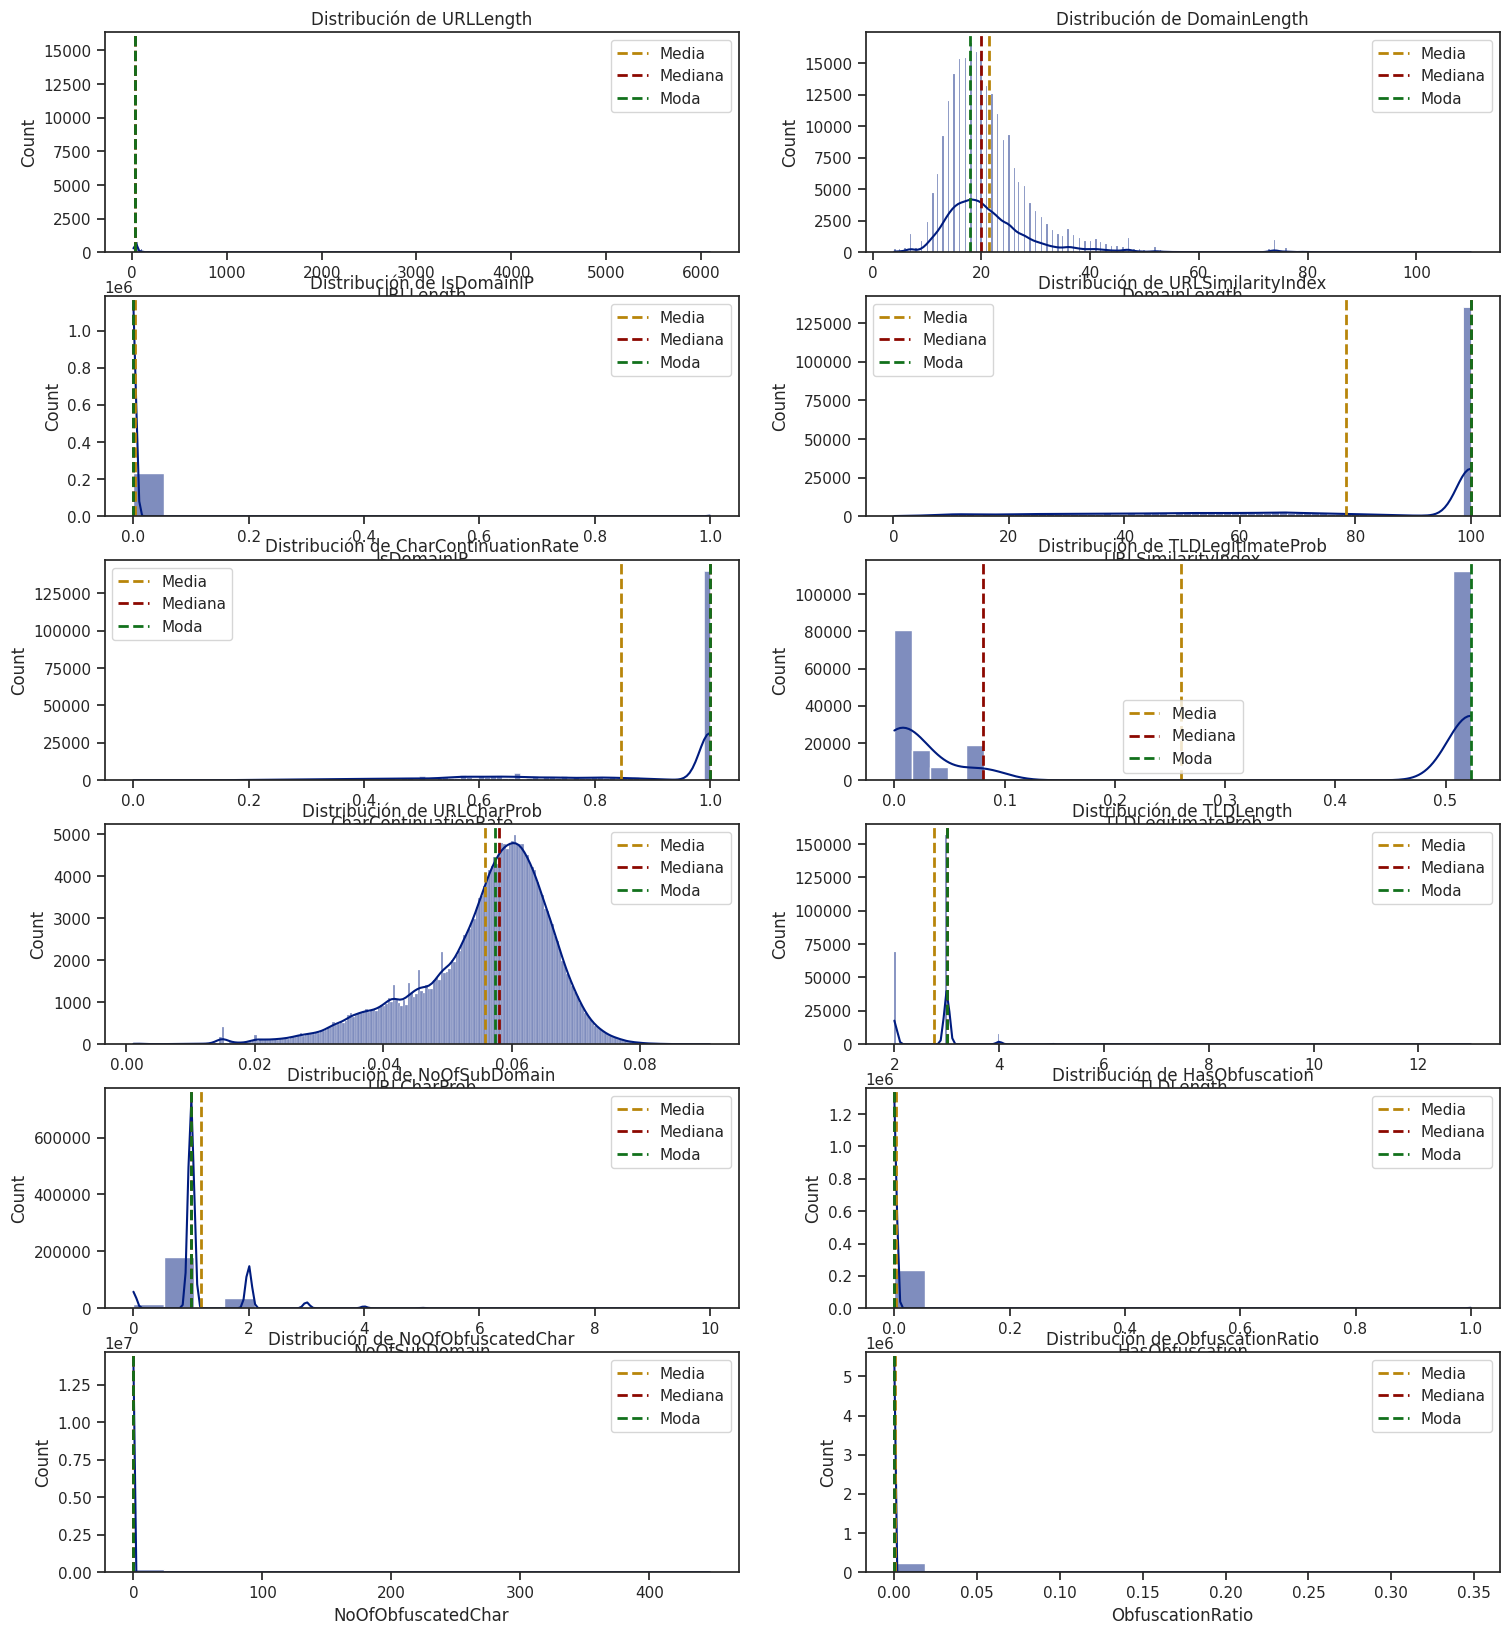

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import mode

# Filtrar solo las columnas numéricas
columnas_numericas = df.select_dtypes(include=[np.number]).columns

# Lista de las variables numéricas
variables = list(columnas_numericas)

# Crear la figura
fig = plt.figure(figsize=(18, 20))

# Iterar sobre las variables numéricas
for index, variable in enumerate(variables):
    # Calcular la media, mediana y moda de cada variable
    media = df[variable].mean()  # Media
    mediana = df[variable].median()  # Mediana
    moda = mode(df[variable])[0].item()  # Moda

    # Crear un subgráfico para cada variable
    plt.subplot(6, 2, index+1)

    # Crear histograma y KDE (Kernel Density Estimation)
    sns.histplot(df[variable], kde=True)

    # Agregar líneas para media, mediana y moda
    plt.axvline(media, color='y', linestyle='dashed', linewidth=2, label='Media')
    plt.axvline(mediana, color='r', linestyle='dashed', linewidth=2, label='Mediana')
    plt.axvline(moda, color='g', linestyle='dashed', linewidth=2, label='Moda')

    # Agregar título y leyenda
    plt.title(f'Distribución de {variable}')
    plt.legend()

# Ajustar el layout para que no se solapen los gráficos
fig.tight_layout(pad=1.0)

# Mostrar el gráfico
plt.show()


1. ¿Qué factores influyen más en la clasificación de una URL como phishing o no phishing?
2. ¿Cuál es el impacto de la obfuscación en la clasificación de una URL como phishing?
3. ¿Existe una relación entre la longitud de la URL y la clasificación de la URL como phishing o no phishing?
4. ¿Cómo afecta la presencia de información de copyright a la clasificación de la URL?
